# Homework 3 - PHYS 512

Élyse D'Aoust

261335942

## Question 1 - Crank-Nicolson diffusion

Part a)

We have:

$$ T_{j}^{n+1} = T_{j}^{n} + \frac{\alpha}{2} \left( T_{j+1}^{n} - 2T_{j}^{n} + T_{j-1}^{n} \right) + \frac{\alpha}{2}\left( T_{j+1}^{n+1} - 2T_{j}^{n+1} + T_{j-1}^{n+1} \right)  \tag{1} $$

To check the stability of the method, let's look for a solution $T_{j}^{n} = \xi^{n}e^{ikx} = \xi^{n}e^{ik(j\Delta x)} $ . Substituting this into $(1)$, we get:

$$
\xi^{n+1}e^{ik(j\Delta x)} = \xi^{n}e^{ik(j\Delta x)} + \frac{\alpha}{2} \left( \xi^{n}e^{ik((j+1)\Delta x)} -2\xi^{n}e^{ik(j\Delta x)} + \xi^{n}e^{ik((j-1)\Delta x)} \right) + \frac{\alpha}{2} \left( \xi^{n+1}e^{ik((j+1)\Delta x)} -2\xi^{n+1}e^{ik(j\Delta x)} + \xi^{n+1}e^{ik((j-1)\Delta x)} \right)
$$

$$
\rightarrow \quad \xi^{n+1}e^{ikj\Delta x} = \xi^{n}e^{ikj\Delta x} + \frac{\alpha}{2} \left( e^{ikj\Delta x} \right) \left( \xi^{n}e^{ik\Delta x} -2\xi^{n} + \xi^{n}e^{-ik\Delta x} \right) + \frac{\alpha}{2} \left( e^{ikj\Delta x} \right) \left( \xi^{n+1}e^{ik\Delta x} -2\xi^{n+1} + \xi^{n+1}e^{-ik\Delta x} \right)
$$

Eliminating all $e^{ikj\Delta x}$ from both sides, we get:

$$
\xi^{n+1} = \xi^{n} + \frac{\alpha}{2} \left( \xi^{n} \right) \left( e^{ik\Delta x} -2 + e^{-ik\Delta x} \right) + \frac{\alpha}{2} \left( \xi^{n+1} \right) \left( e^{ik\Delta x} -2 + e^{-ik\Delta x} \right)
$$

Now, dividing both sides by $\left( \xi^{n} \right)$, we get:

$$
\xi = 1 + \frac{\alpha}{2} \left( e^{ik\Delta x} -2 + e^{-ik\Delta x} \right) + \frac{\alpha}{2} \xi \left( e^{ik\Delta x} -2 + e^{-ik\Delta x} \right)
$$

Using $ \frac{e^{ix} + e^{-ix}}{2} = cos(x)$, this gives:

$$
\xi = 1 + \frac{\alpha}{2} \left( 2cos(k\Delta x) - 2 \right) + \frac{\alpha}{2} \xi \left( 2cos(k\Delta x) - 2 \right)
$$

$$
\rightarrow \quad \xi - \alpha \xi \left( cos(k\Delta x) - 1 \right) = 1 + \alpha \left( cos(k\Delta x) - 1 \right)
$$

$$
\rightarrow \quad \xi \left( 1 - \alpha \left( cos(k\Delta x) - 1 \right) \right) = 1 + \alpha \left( cos(k\Delta x) - 1 \right)
$$

$$
\rightarrow \quad \xi = \frac{1 + \alpha \left( cos(k\Delta x) - 1 \right)}{1 - \alpha \left( cos(k\Delta x) - 1 \right)}
$$

Using the identity $cos(\theta) - 1 = -2sin^{2}(\frac{\theta}{2})$, we get:

$$
\xi = \frac{1 - 2\alpha sin^2(\frac{k\Delta x}{2})}{1 + 2\alpha sin^2(\frac{k\Delta x}{2})} \tag{2} 
$$

For stability, we need $\lvert \xi \rvert \leq 1$. The final expression for $\xi$ above, $\left( 2 \right)$, is in the form $\frac{1-y}{1+y}$, which always has an absolute value less than or equal to 1 for nonnegative y values. In our case, we have $y = 2\alpha sin^2(\frac{k\Delta x}{2})$, where $\alpha = \frac{D\Delta t}{\Delta x^2}$ is always positive (since all the variables it depends on must be positive), and $sin^2(\frac{k\Delta x}{2})$ must be positive (because of the square) or equal to zero, meaning that we have a nonnegative $y$. Therefore, since $\lvert 1 - 2\alpha sin^2(\frac{k\Delta x}{2}) \rvert \leq \lvert 1 + 2\alpha sin^2(\frac{k\Delta x}{2}) \rvert$, we have that $\lvert \xi \rvert = \lvert \frac{1 - 2\alpha sin^2(\frac{k\Delta x}{2})}{1 + 2\alpha sin^2(\frac{k\Delta x}{2})} \rvert \leq 1$. This means that the Crank-Nicolson method applied to diffusion is always stable for all values of $\alpha$.

Part b)

The result from part (a) implies that when $\alpha$ is large, the method remains stable. However, while $T_j$ will not blow up for very large values of $\alpha$, this does not prevent it from oscillating (as will be observed in part c)). Indeed, as $\alpha \rightarrow \infty$, we have that $2\alpha sin^2(\frac{k\Delta x}{2}) \rightarrow \infty$. Rewriting $(2)$ as:

$$
\xi = \frac{\frac{1}{2\alpha sin^2(\frac{k\Delta x}{2})} - 1}{\frac{1}{2\alpha sin^2(\frac{k\Delta x}{2})} + 1}, \tag{2} 
$$

we can see that as $2\alpha sin^2(\frac{k\Delta x}{2}) \rightarrow \infty$, we get $\xi \rightarrow -1$. Since we defined a solution $T_{j}^{n} = \xi^{n}e^{ik(j\Delta x)}$, we can see that the $\xi^{n} = (-1)^{n}$ term will converge to alternating between $-1$ and $1$ in the $\alpha \rightarrow \infty$ limit. Therefore, this leads to alternating signs between successive timesteps, leading to some oscillation artefacts.

For the fully-implicit method, let's conduct the same von Neumann stability analysis. The fully-implicit method uses the following update:

$$
T_{i}^{n+1} = T_{i}^{n} + \alpha \left( T_{i+1}^{n+1} - 2T_{i}^{n+1} + T_{i-1}^{n+1} \right)
$$

Using a solution $T_{j}^{n} = \xi^{n}e^{ikj\Delta x}$ like in part a), and substituting this into the equation above, we get:

$$
\xi^{n+1}e^{ikj\Delta x} = \xi^{n}e^{ikj\Delta x} + \alpha\left( \xi^{n+1}e^{ik((j+1)\Delta x)} -2\xi^{n+1}e^{ikj\Delta x} + \xi^{n+1}e^{ik((j-1)\Delta x)} \right)
$$

Dividing by $\xi^{n}$ and by $e^{ikj\Delta x}$ on both sides, and using the same trigonometric identities as above, we get:

$$
\xi = 1 + \alpha\xi\left( e^{ik\Delta x} + e^{-ik\Delta x} - 2 \right)
$$

$$
\rightarrow \quad \xi = 1 + \alpha\xi\left( 2cos(k\Delta x) - 2 \right)
$$

$$
\rightarrow \quad \xi - 2\alpha\xi\left( cos(k\Delta x) - 1 \right) = 1
$$

$$
\rightarrow \quad \xi\left( 1 - 2\alpha\left( cos(k\Delta x) - 1 \right) \right) = 1
$$

$$
\rightarrow \quad \xi = \frac{1}{1 - 2\alpha\left( cos(k\Delta x) - 1 \right)}
$$

$$
\rightarrow \quad \xi = \frac{1}{1 + 4\alpha sin^2(\frac{k\Delta x}{2})}
$$

Therefore, knowing that $4\alpha sin^2(\frac{k\Delta x}{2})$ must be nonnegative (for the same reasons as explained in part a)), we can automatically see that $\lvert \xi \rvert \leq 1$ for all values of $\alpha$, meaning that the fully-implicit method is also unconditionally stable. However, in this case, as $\alpha \rightarrow \infty$, we have $1 + 4\alpha sin^2(\frac{k\Delta x}{2}) \rightarrow \infty$, therefore $\xi \rightarrow 0$. So, for the fully-implicit method, no oscillation occurs as $\alpha$ grows very large. Instead, the modes get increasingly damped as $\alpha \rightarrow \infty$, since we have defined $T_{j}^{n} = \xi^{n}e^{ikj\Delta x}$.

Part c)

To implement the Crank-Nicolson update in the code from class, we need to determine how to write the update in terms of matrices, and define the required matrices. For the Crank-Nicolson update, defined by:

$$ 
T_{j}^{n+1} = T_{j}^{n} + \frac{\alpha}{2} \left( T_{j+1}^{n} - 2T_{j}^{n} + T_{j-1}^{n} \right) + \frac{\alpha}{2}\left( T_{j+1}^{n+1} - 2T_{j}^{n+1} + T_{j-1}^{n+1} \right),
$$

we can isolate all $T^{n+1}$ terms on one side of the equation, and all $T^{n}$ terms on the other side, giving:

$$
-\alpha T_{j+1}^{n+1} + 2\left( 1 + \alpha \right)T_{j}^{n+1} - \alpha T_{j-i}^{n+1} = \alpha T_{j+1}^{n} + 2\left( 1 - \alpha \right)T_{j}^{n} + \alpha T_{j-1}^{n}
$$

Therefore, we can write the update as:

$$
\mathbf{AT}^{n+1} = \mathbf{BT}^{n}
$$

With the following matrices for $\mathbf{A}$ and $\mathbf{B}$, taking $N=5$ here for an example:

$$
A = \begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\
-\alpha & 2+2\alpha & -\alpha & 0 & 0 \\
0 & -\alpha & 2+2\alpha & -\alpha & 0 \\
0 & 0 & -\alpha & 2+2\alpha & -\alpha \\
0 & 0 & 0 & 0 & 1 
\end{pmatrix}
$$

$$
B = \begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\
\alpha & 2-2\alpha & \alpha & 0 & 0 \\
0 & \alpha & 2-2\alpha & \alpha & 0 \\
0 & 0 & \alpha & 2-2\alpha & \alpha \\
0 & 0 & 0 & 0 & 1 
\end{pmatrix}
$$

Code implementation:

In [48]:
# Code taken from class solutions and adapted

import numpy as np
import matplotlib.pyplot as plt

# Function to define matrix A for fully-implicit method
def calculate_Aimp(alpha,N):
    b = (1+2*alpha) * np.ones(N) # diagonal
    a = -alpha * np.ones(N) # upper diagonal
    c = -alpha * np.ones(N) # lower diagonal

    # boundary conditions: the temperatures at the ends are fixed
    # so we need to adjust the matrix to give T_end^(n+1) = T_end^n
    # x=0
    b[0] = 1.0
    a[1] = 0.0
    # x=1
    b[-1] = 1.0
    c[-2] = 0.0
    # construct the matrix
    return np.vstack((a,b,c))

# Function to define matrix A for Crank-Nicolson method
def calculate_A(alpha,N):
    b = (2+2*alpha) * np.ones(N) # diagonal
    a = -alpha * np.ones(N) # upper diagonal
    c = -alpha * np.ones(N) # lower diagonal

    # boundary conditions: the temperatures at the ends are fixed
    # so we need to adjust the matrix to give T_end^(n+1) = T_end^n
    # x=0
    b[0] = 1.0
    a[1] = 0.0
    # x=1
    b[-1] = 1.0
    c[-2] = 0.0
    # construct the matrix
    return np.vstack((a,b,c))

# Function to define matrix B for Crank-Nicolson method
def calculate_B(alpha,N):
    b = (2-2*alpha) * np.ones(N) # diagonal
    a = alpha * np.ones(N) # upper diagonal
    c = alpha * np.ones(N) # lower diagonal
    
    # boundary conditions: the temperatures at the ends are fixed
    # so we need to adjust the matrix to give T_end^(n+1) = T_end^n
    # x=0
    b[0] = 1.0
    a[1] = 0.0
    # x=1
    b[-1] = 1.0
    c[-2] = 0.0
    # construct the matrix
    return np.diag(b, k=0) + np.diag(a[1:], k=1) + np.diag(c[:-1], k=-1)

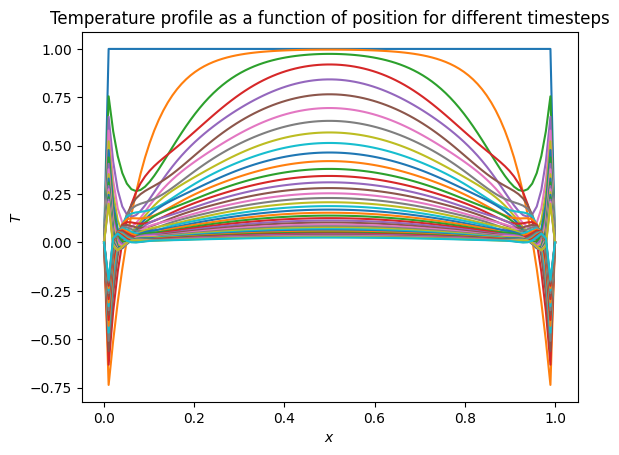

In [50]:
# Code taken from class solutions and adapted

import time
import scipy

# Defining the grid
N = 100 # number of grid points
x = np.linspace(0, 1, N)

alpha = 100 # alpha = D*dt/(dx**2), measures the timestep
nsteps = 40 # number of time steps

# Initial profile has T=1 everywhere except T=0 at the boundaries
T = np.ones(N)

# boundaries
T[0] = 0.0
T[-1] = 0.0

# Plot initial temperature profile
plt.plot(x, T)
plt.xlabel(r'$x$')
plt.ylabel(r'$T$')
plt.title("Temperature profile as a function of position for different timesteps")

# Calculate the Crank-Nicolson update

# Calculate the matrices
A_CN = calculate_A(alpha,N)
B_CN = calculate_B(alpha,N)

# Update T for each timestep
for i in range(1,nsteps):
    BT = B_CN@T # First do matrix multiplication between matrix B and T
    T = scipy.linalg.solve_banded((1,1), A_CN, BT)

    # Plot temperature profile at this timestep
    plt.plot(x, T)

plt.show()

Now, replacing the first 5 steps with fully-implicit steps:

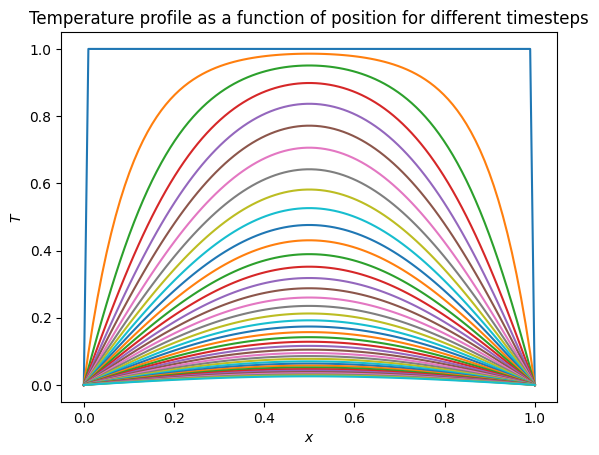

In [51]:
# Code taken from class solutions and adapted

import time
import scipy

# Defining the grid
N = 100 # number of grid points
x = np.linspace(0, 1, N)

alpha = 100 # alpha = D*dt/(dx**2), measures the timestep
nsteps = 40 # number of time steps
nsteps_implicit = 5 # number of steps done using the fully-implicit method before switching to Crank-Nicolson

# Initial profile has T=1 everywhere except T=0 at the boundaries
T = np.ones(N)

# boundaries
T[0] = 0.0
T[-1] = 0.0

# Plot initial temperature profile
plt.plot(x, T)
plt.xlabel(r'$x$')
plt.ylabel(r'$T$')
plt.title("Temperature profile as a function of position for different timesteps")

# Calculate the matrices for the implicit and Crank-Nicolson updates
Aimp = calculate_Aimp(alpha, N)
A_CN = calculate_A(alpha,N)
B_CN = calculate_B(alpha,N)

# Update T for each timestep
for i in range(1,nsteps):
    # Use the fully-implicit method for the first 5 steps
    if (i<=nsteps_implicit):
        T = scipy.linalg.solve_banded((1,1), Aimp, T)
    else:
        BT = B_CN@T # First do matrix multiplication between matrix B and T
        T = scipy.linalg.solve_banded((1,1), A_CN, BT)

    # Plot temperature profile at this timestep
    plt.plot(x, T)

plt.show()

Therefore, the behaviour described in part b) was indeed observed when comparing the Crank-Nicolson method with large $\alpha$ and the mixed fully-implicit/Crank-Nicolson method. Indeed, when using the Crank-Nicolson method only, we can observe oscillatory behaviour in the temperature profiles. This was explained in part b), as it was shown that increasing values of $\alpha$ would lead to modes of alternating signs between successive timesteps. However, when running a few steps of the fully-implicit method before switching to the Crank-Nicolson method, we greatly reduce the oscillatory behaviour. Indeed, the sharp discontinuity that results from setting boundary conditions for the first temperature profile (namely that the T=0 at both boundaries) is the most problematic with the oscillatory behaviour of Crank-Nicolson, and this issue is therefore avoided by using the fully-implicit method to handle these first few updates. Therefore, performing a few steps of the fully-implicit method at the beginning before switching to Crank-Nicolson gets us the expected solution for temperature diffusion, and removes the visible oscillations.

Part d)

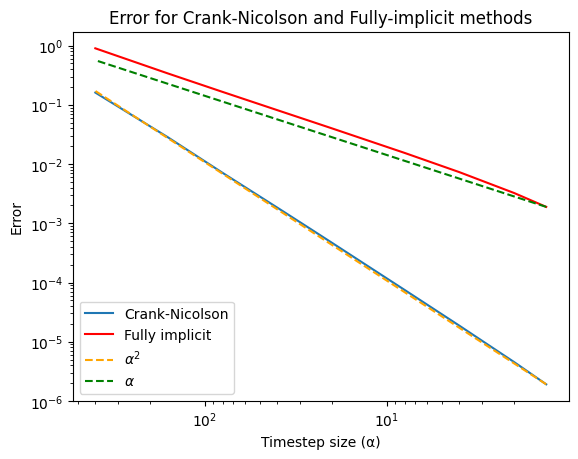

In [ ]:
# Code taken from class solutions and adapted

import scipy

# Defining the grid
N = 100 # number of grid points
x = np.linspace(0, 1, N)

total_time = 4000 # fixed total time (alpha*nsteps)
nsteps = np.array([10000, 3000, 2000, 1000, 500, 200, 150, 100, 50, 25, 10]) # array of all the values of nsteps to try
alpha = total_time/nsteps # calculate alpha based on the fixed total time
nsteps_implicit = 3 # number of steps for which we will use the fully-implicit method before switching to Crank-Nicolson

# Define arrays that will contain the values for dT/dx for both methods
dT_dx_cn = np.zeros(len(nsteps))
dT_dx_imp = np.zeros(len(nsteps))


# Crank-Nicolson method:
# Loop over all values of nsteps
for i,j in enumerate(nsteps):
    # Initial profile has T=1 everywhere except T=0 at the boundaries
    T = np.ones(N)

    # boundaries
    T[0] = 0.0
    T[-1] = 0.0

    # Calculate matrices for Crank-Nicolson and fully-implicit methods
    Aimp = calculate_Aimp(alpha[i], N)
    A_CN = calculate_A(alpha[i],N)
    B_CN = calculate_B(alpha[i],N)

    # Get temperature profile for each timestep
    for k in range(1,j+1):
        # Use the fully-implicit method for the first few steps (as instructed by the professor)
        if (k<=nsteps_implicit):
            T = scipy.linalg.solve_banded((1,1), Aimp, T)
        else:
            BT = B_CN@T # First do matrix multiplication between matrix B and T
            T = scipy.linalg.solve_banded((1,1), A_CN, BT)

    # Calculate dT/dx at x=0
    dT_dx_cn[i] = (T[1]-T[0])/(x[1]-x[0])


# Fully-implicit method:
# Loop over all values of nsteps
for i,j in enumerate(nsteps):
    # Initial profile has T=1 everywhere except T=0 at the boundaries
    T = np.ones(N)

    # boundaries
    T[0] = 0.0
    T[-1] = 0.0

    # Calculate matrix for fully-implicit method
    Aimp = calculate_Aimp(alpha[i], N)

    # Get temperature profile for each timestep
    for k in range(1,j+1):
        T = scipy.linalg.solve_banded((1,1), Aimp, T)

    # Calculate dT/dx at x=0
    dT_dx_imp[i] = (T[1]-T[0])/(x[1]-x[0])


# Calculate the errors (for the actual value, use the value of dT_dx at the smallest timestep)

# Crank Nicolson method
err_cn = np.abs((dT_dx_cn - dT_dx_cn[0])/dT_dx_cn[0])

# Fully-implicit method
err_imp = np.abs((dT_dx_imp - dT_dx_imp[0])/dT_dx_imp[0])

# Plot the errors (ignoring the first value, since that was used as our reference for the error and so gives an error of 0)
plt.loglog(alpha[1:], err_cn[1:], label='Crank-Nicolson')
plt.loglog(alpha[1:], err_imp[1:], label='Fully implicit', color='red')
plt.loglog(alpha[1:], (err_cn[1]/(alpha[1]**2))*alpha[1:]**2, linestyle='--', label=f'$α^2$', color='orange') # reference for α^2 (shifted to line up with the Crank-Nicolson error)
plt.loglog(alpha[1:], (err_imp[1]/alpha[1])*alpha[1:], linestyle='--', label=f'$α$', color='green') # reference for α (shifted to line up with the Fully implicit method error)
plt.title("Error for Crank-Nicolson and Fully-implicit methods")
plt.xlabel("Timestep size (α)")
plt.ylabel("Error")
plt.gca().invert_xaxis() # invert x axis, so it goes from  biggest to smallest timestep
plt.legend(loc='lower left')
plt.show()

Therefore, from the log-log plot above (where the timesteps on the x axis are in decreasing order), we can see that the relative  error $\propto \alpha^2$ for the Crank-Nicolson method. Indeed, the slope of the error vs the timestep ($\alpha$) is of around 2 on the log-log plot (appearing like -2 given the inverted x axis), meaning that the error decreases quadratically with decreasing timesteps. Therefore, this confirms that the Crank-Nicolson method is second order in time. On the other hand, the relative error for the fully-implicit method plotted against the timestep follows the slope of approximately 1 like for $y=\alpha$, meaning that the relative error $\propto \alpha$. Therefore, we know that the error for the fully-implicit method scales as $\alpha$ (which represents the timestep), meaning that it is indeed first order in time.

## Question 2 - Reflection and transmission of an electromagnetic wave

Part a)

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def propagate(sign, n, N, total_time, nsteps, frames):
    n = n # refractive index

    # Make the spatial grid
    N = N # total number of grid points
    x = np.linspace(0, 1, N)
    dx = x[1]-x[0] # calculate spatial spacing

    # Define timesteps
    total_time = total_time # total time
    nsteps = nsteps # number of time steps
    dt = total_time/nsteps # calculate temporal spacing

    # Define Gaussian profile for E and B (at t=0)
    sig = 0.04
    E = np.exp(-(x-0.5)**2 /(2*sig**2))
    B = sign*(np.copy(E)) # B has the same profile as E, either with the same or opposite signs (depending on if the parameter sign is +1 or -1)

    E_n = np.copy(E) # E at time n (which will initially be 0)
    B_n = np.copy(B) # B at time n (which will initially be 0)

    # Calculate the first time step separately: We use the first order time derivative instead of the second order one for the time derivative, since we don't have anything for time n-1
    for i in range (0, N):
        if (i==0):
            # For the first point on the grid, assume that E = 0 at the boundary, and assume that E_{i-1} = E_{i}
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i+1] - E_n[i])
            E[i] = 0
        elif (i==(N-1)):
            # For the last point on the grid, assume that E = 0 at the boundary, and assume that E_{i+1} = E_{i}
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i] - E_n[i-1])
            E[i] = 0
        else:
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i+1] - E_n[i-1])
            E[i] = E_n[i] - (dt/(2*dx))*(B_n[i+1] - B_n[i-1])*(1/n**2)

    E_n_1 = np.copy(E_n) # E at time n-1 (time 0)
    B_n_1 = np.copy(B_n) # B at time n-1 (time 0)

    E_n = np.copy(E) # E at time n (which is now at time 1*dt)
    B_n = np.copy(B) # B at time n (which is now at time 1*dt)

    # Create arrays to store some of the E and B arrays at chosen timesteps
    E_saved = [np.copy(E_n_1), np.copy(E_n)] # initially save E at the first two timesteps
    B_saved = [np.copy(B_n_1), np.copy(B_n)] # initially save B at the first two timesteps
    frame_times = [0, dt] # array to save the times at which E and B were saved

    # Do the update for the rest of the timesteps with the given update scheme
    for k in range (2,nsteps+1):
        # For each timestep, update the value of E and B at each grid point
        for i in range (0, N):
            if (i==0):
                # For the first point on the grid, assume that E=0 at the boundary and that E_{i-1} = E_{i} (for calculating B_{i})
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i+1] - E_n[i])
                E[i] = 0
            elif (i==(N-1)):
                # For the last point on the grid, assume that E=0 at the boundary and that E_{i+1} = E_{i} (for calculating B_{i})
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i] - E_n[i-1])
                E[i] = 0
            else:
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i+1] - E_n[i-1])
                E[i] = E_n_1[i] - (dt/dx)*(B_n[i+1] - B_n[i-1])*(1/n**2)

        # Move time indices forward for next iteration
        E_n_1 = np.copy(E_n)
        B_n_1 = np.copy(B_n)
        E_n = np.copy(E)
        B_n = np.copy(B)

        # For given times, save E and B
        if (k in frames):
            E_saved.append(np.copy(E))
            B_saved.append(np.copy(B))
            frame_times.append(k*dt)

    return E_saved, B_saved, frame_times, x

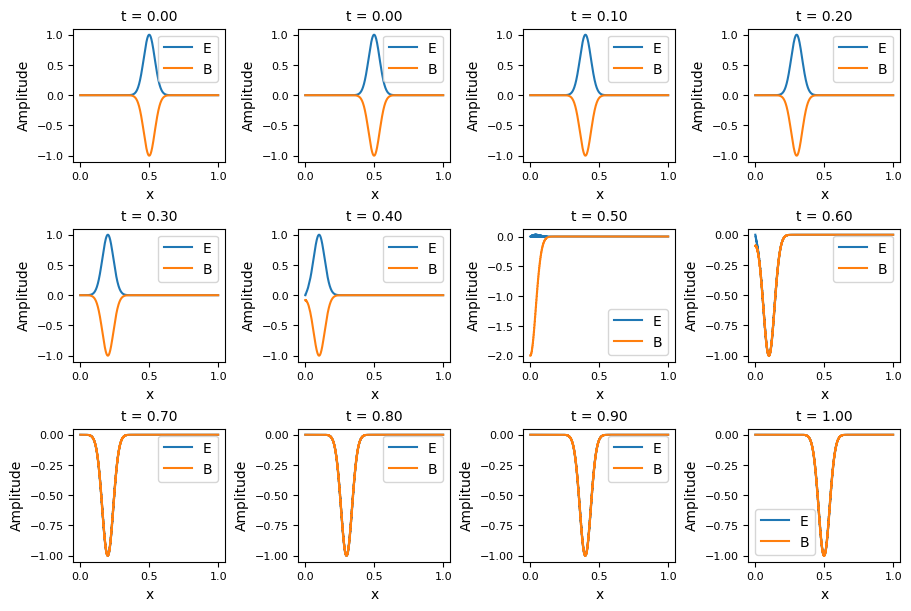

In [59]:
frames = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000] # with my chosen dt and grid size, these frames (given the wave speed of 1) would allow me to see one back and forth trip of the wave in snapshots

# Get the saved values of E, B and t after propagation (with B=-E)
E, B, frame_times, x = propagate(-1, 1, 1000, 10, 10000, frames)

# Define plotting grid
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(9, 6), layout="constrained")

# Plot grid of snapshots for the 12 chosen frames
for row in range(3):
    for col in range(4):
        ax = axs[row, col] # Select the specific small plot
        ax.plot(x, E[row*4 + col], label='E') # index chosen to go from plot 1 to 12
        ax.plot(x, B[row*4 + col], label='B')
        ax.set_title(f"t = {frame_times[row*4 + col]:.2f}", fontsize=10)
        ax.set_xlabel('x')
        ax.set_ylabel('Amplitude')
        ax.legend()
        ax.tick_params(labelsize=8) # Keep tick labels small

plt.show()

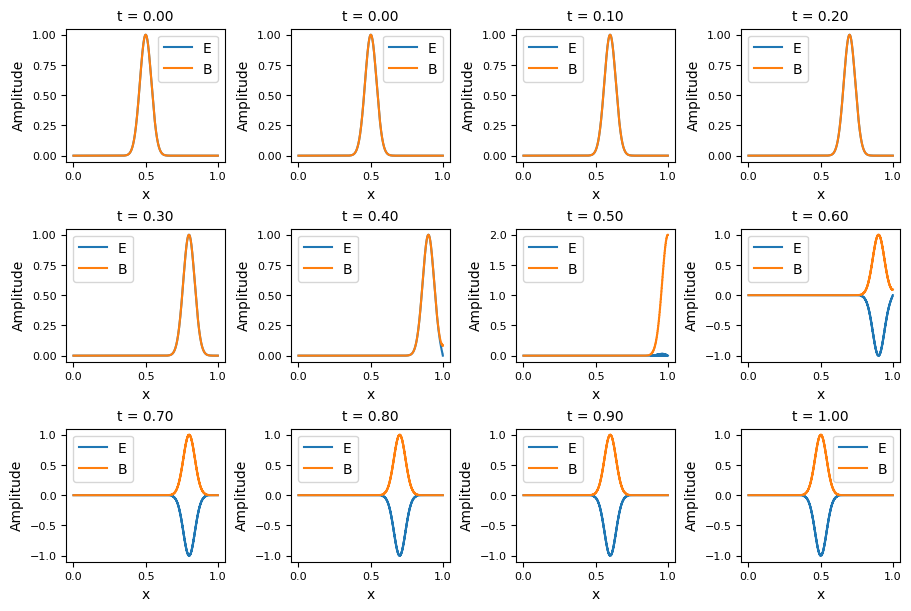

In [58]:
frames = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000] # with my chosen dt and grid size, these frames (given the wave speed of 1) would allow me to see one back and forth trip of the wave in snapshots

# Get the saved values of E, B and t after propagation (with B=E)
E, B, frame_times, x = propagate(1, 1, 1000, 10, 10000, frames)

# Define plotting grid
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(9, 6), layout="constrained")

# Plot grid of snapshots for the 12 chosen frames
for row in range(3):
    for col in range(4):
        ax = axs[row, col] # Select the specific small plot
        ax.plot(x, E[row*4 + col], label='E') # index chosen to go from plot 1 to 12
        ax.plot(x, B[row*4 + col], label='B')
        ax.set_title(f"t = {frame_times[row*4 + col]:.2f}", fontsize=10)
        ax.set_xlabel('x')
        ax.set_ylabel('Amplitude')
        ax.legend()
        ax.tick_params(labelsize=8) # Keep tick labels small

plt.show()

From the two grids above, we can see that for E and B with the same profile and same sign, the wave propagates towards the right at the start. On the other hand, for E and B with the same profile but opposite signs, the wave initially propagates towards the left. This is expected, since the wave propagation direction can be determined by taking the cross product of E and B. Therefore, flipping the B components (adding a negative sign) would flip the direction of propagation (which is easily verifiable using the right hand rule). Also, changing the sign of B inverts the direction of the amplitude compared to E. From the two grids, we can also tell that the Gaussian does in fact propagate without changing shape, until encountering a boundary. When it encounters a boundary, the sign of the electric field's amplitude flips, but the absolute values of both the E and B amplitudes remains the same. At the boundaries, an amplitude of 2 or -2 can be observed, which is an unexpected behaviour. However, these are numerical artifacts associated with the imposed boundary conditions, and are not representative of the wave propagation in the medium.

Part b)

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def propagate_different_n(sign, n1, n2, N, total_time, nsteps, frames):

    # Make the spatial grid
    N = N # number of grid points
    x = np.linspace(0, 1, N)
    dx = x[1]-x[0] # calculate spatial spacing

    # Define timesteps
    total_time = total_time # total time
    nsteps = nsteps # number of time steps
    dt = total_time/nsteps # calculate temporal spacing

    # Define Gaussian profile for E and B (at t=0)
    sig = 0.04
    E = np.exp(-(x-0.25)**2 /(2*sig**2))
    B = sign*n1*(np.copy(E))

    E_n = np.copy(E) # E at time n
    B_n = np.copy(B) # B at time n

    # Calculate the first time step separately: We use the first order time derivative instead of the second order one for the time derivative, since we don't have anything for time n-1
    for i in range (0, N):
        if (i==0):
            # For the first point on the grid, assume that E=0 at the boundary, and that E_{i-1} = E_{i} for calculating B_{i}
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i+1] - E_n[i])
            E[i] = 0
        elif (i==(N-1)):
            # For the last point on the grid, assume that E=0 at the boundary, and that E_{i+1} = E_{i} for calculating B_{i}
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i] - E_n[i-1])
            E[i] = 0
        elif (i>(N/2)):
            # In this case, we have refractive index n2 (right side of the grid)
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i+1] - E_n[i-1])
            E[i] = E_n[i] - (dt/(2*dx))*(B_n[i+1] - B_n[i-1])*(1/n2**2)
        else:
            # In this case, we have refractive index n1 (left side of the grid)
            B[i] = B_n[i] - (dt/(2*dx))*(E_n[i+1] - E_n[i-1])
            E[i] = E_n[i] - (dt/(2*dx))*(B_n[i+1] - B_n[i-1])*(1/n1**2)

    E_n_1 = np.copy(E_n) # E at time n-1
    B_n_1 = np.copy(B_n) # B at time n-1

    E_n = np.copy(E) # E at time n
    B_n = np.copy(B) # B at time n

    # Create arrays to store some of the E and B arrays at chosen timesteps
    E_saved = [np.copy(E_n_1), np.copy(E_n)] # initially save E at the first two timesteps
    B_saved = [np.copy(B_n_1), np.copy(B_n)] # initially save B at the first two timesteps
    frame_times = [0, dt] # array to save the times at which E and B were saved

    # Do the update for the rest of the timesteps with the given update scheme
    for k in range (2,nsteps+1):
        # For each timestep, update the value of E and B at each grid point
        for i in range (0, N):
            if (i==0):
                # For the first point on the grid, assume that E=0 at the boundary, and that E_{i-1} = E_{i} for calculating B_{i}
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i+1] - E_n[i])
                E[i] = 0
            elif (i==(N-1)):
                # For the last point on the grid, assume that E=0 at the boundary, and that E_{i+1} = E_{i} for calculating B_{i}
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i] - E_n[i-1])
                E[i] = 0
            elif(i>(N/2)):
                # In this case, we have refractive index n2 (right side of the grid)
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i+1] - E_n[i-1])
                E[i] = E_n_1[i] - (dt/dx)*(B_n[i+1] - B_n[i-1])*(1/n2**2)
            else:
                # In this case, we have refractive index n1 (left side of the grid)
                B[i] = B_n_1[i] - (dt/dx)*(E_n[i+1] - E_n[i-1])
                E[i] = E_n_1[i] - (dt/dx)*(B_n[i+1] - B_n[i-1])*(1/n1**2)

        # Move time indices forward for next iteration
        E_n_1 = np.copy(E_n)
        B_n_1 = np.copy(B_n)
        E_n = np.copy(E)
        B_n = np.copy(B)

        # For given times, save E and B
        if (k in frames):
            E_saved.append(np.copy(E))
            B_saved.append(np.copy(B))
            frame_times.append(k*dt)

    return E_saved, B_saved, frame_times, x

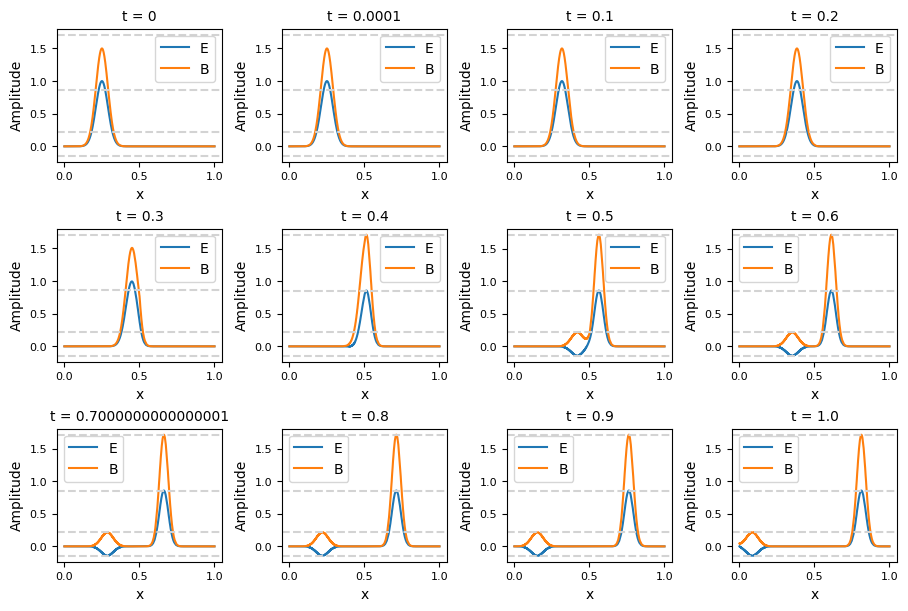

In [64]:
frames = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000] # with my chosen dt and grid size, these frames (given the wave speed of 1) would allow me to see one back and forth trip of the wave in snapshots

# Get the saved values of E, B and t after propagation (with B=E)
E, B, frame_times, x = propagate_different_n(1, 1.5, 2, 1000, 10, 100000, frames)

# Define plotting grid
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(9, 6), layout="constrained")

# Plot grid of snapshots for the 12 chosen frames
for row in range(3):
    for col in range(4):
        ax = axs[row, col] # Select the specific small plot
        ax.plot(x, E[row*4 + col], label='E') # index chosen to go from plot 1 to 12
        ax.plot(x, B[row*4 + col], label='B')
        ax.axhline(y=-0.143, linestyle='--', color='lightgrey')
        ax.axhline(y=0.857, linestyle='--', color='lightgrey')
        ax.axhline(y=1.71, linestyle='--', color='lightgrey')
        ax.axhline(y=0.214, linestyle='--', color='lightgrey')
        ax.set_title(f"t = {frame_times[row*4 + col]}", fontsize=10)
        ax.set_xlabel('x')
        ax.set_ylabel('Amplitude')
        ax.legend()
        ax.tick_params(labelsize=8) # Keep tick labels small

plt.show()

Initially, the Gaussian pulse is placed in the left medium, with $n_1 = 1.5$, and made to travel to the right with $B = n_1 E = 1.5E$ (which is observed from the initial amplitudes of 1 for E_i 1.5 for B_i). When the pulse reaches the interface, it splits into a transmitted pulse that continues in the second medium, and a reflected pulse that travels back into the initial medium. The expected behaviour of the wave amplitude is indeed observed when the pulse encounters the change in n at the middle of the grid. Indeed, from the reflection and transmission coefficients, with $n_1 = 1.5$ and $n_2 = 2$, we have ():

$$
r = \frac{n_1 - n_2}{n_1 + n_2} = \frac{1.5 - 2}{1.5 + 2} = \frac{-0.5}{3.5} \approx -0.143
$$

$$
t = \frac{2n_1}{n_1 + n_2} = \frac{2(1.5)}{1.5 + 2} = \frac{3}{3.5} \approx 0.857
$$

Therefore, we expect $E_r = -0.143E_i$ (the negative sign meaning that the amplitude is also flipped) and $E_t = 0.857E_i$. This is exactly what is observed in the plots above, and light gray dashed lines were added at these expected reflected and transmitted amplitudes in order to observe this. Also, knowing $B = nE$, we can also calculate $B_r = -1.5E_r \approx 0.214E_i$, and $B_t = 2E_t \approx 1.71E_i$. Also, the transmitted pulse travels more slowly, since we have $v_2 = \frac{1}{n_2} = 0.5 < v_1 = \frac{1}{1.5} \approx 0.67$.
